# Housing EDA

In [1]:
##Importing packages
import pandas as pd
import matplotlib.pyplot as plt
# import seaborn as sns
%matplotlib inline

# Importing Dataset

In [2]:
Housing = pd.read_csv("housing.csv")
Housing

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.000000,0.165514,0.067815,0.0,0.273696,0.455845,0.495675,0.238389,0.000000,0.188979,0.252496,0.693147,0.085884,3.218876
1,0.000236,0.000000,0.242302,0.0,0.159428,0.436962,0.578128,0.299335,0.042560,0.099811,0.440312,0.693147,0.186040,3.117950
2,0.000236,0.000000,0.242302,0.0,0.159428,0.527320,0.469617,0.299335,0.042560,0.099811,0.440312,0.688003,0.061533,3.575151
3,0.000293,0.000000,0.063050,0.0,0.139941,0.505947,0.365901,0.370559,0.083382,0.064658,0.500130,0.690281,0.032843,3.538057
4,0.000705,0.000000,0.063050,0.0,0.139941,0.523014,0.424170,0.370559,0.083382,0.064658,0.500130,0.693147,0.094708,3.616309
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.000633,0.000000,0.420455,0.0,0.327021,0.458029,0.519848,0.115711,0.000000,0.151967,0.638489,0.686938,0.198109,3.152736
502,0.000438,0.000000,0.420455,0.0,0.327021,0.398993,0.565337,0.100111,0.000000,0.151967,0.638489,0.693147,0.184664,3.072693
503,0.000612,0.000000,0.420455,0.0,0.327021,0.503402,0.645695,0.090189,0.000000,0.151967,0.638489,0.693147,0.102459,3.214868
504,0.001160,0.000000,0.420455,0.0,0.327021,0.482097,0.636473,0.108419,0.000000,0.151967,0.638489,0.688788,0.123165,3.135494


# Understanding Dataset

In [3]:
## Understanding the data types
Housing.dtypes

CRIM       float64
ZN         float64
INDUS      float64
CHAS       float64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD        float64
TAX        float64
PTRATIO    float64
B          float64
LSTAT      float64
MEDV       float64
dtype: object

In [4]:
##Check for missing Value and count them
Housing.isna().value_counts()

CRIM   ZN     INDUS  CHAS   NOX    RM     AGE    DIS    RAD    TAX    PTRATIO  B      LSTAT  MEDV 
False  False  False  False  False  False  False  False  False  False  False    False  False  False    506
Name: count, dtype: int64

In [5]:
## Conducting simple Stat on our Data
Housing.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,0.036362,0.090296,0.391378,0.047945,0.284651,0.416052,0.500107,0.206017,0.282694,0.328215,0.473075,0.631214,0.252679,3.085437
std,0.077805,0.175973,0.251479,0.176055,0.170604,0.088357,0.186799,0.146027,0.249808,0.215915,0.153716,0.151792,0.144934,0.386966
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.791759
25%,0.000851,0.000000,0.173387,0.000000,0.123710,0.368380,0.360350,0.084579,0.122602,0.161755,0.412532,0.665637,0.134565,2.891757
50%,0.002808,0.000000,0.338343,0.000000,0.273696,0.410307,0.570007,0.173069,0.160343,0.241298,0.522455,0.686240,0.235648,3.100092
75%,0.040430,0.117783,0.646628,0.000000,0.399963,0.461718,0.662162,0.314141,0.693147,0.649259,0.592504,0.692296,0.350738,3.258097
max,0.693147,0.693147,1.000000,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,0.693147,3.931826


# Checking for Relationship and Correlation 

<Axes: title={'center': 'Distribution of MEDV'}, ylabel='Frequency'>

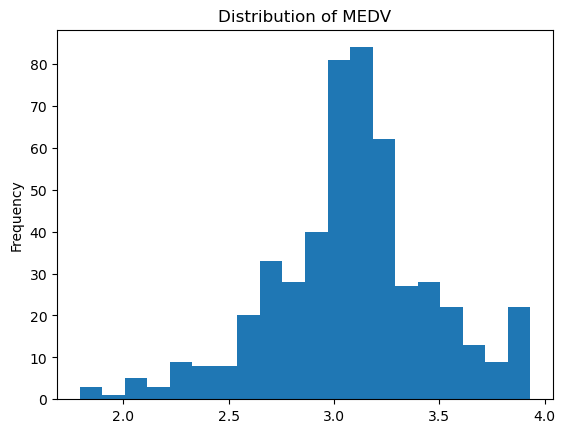

In [6]:
Housing["MEDV"].plot(kind="hist", 
                     bins=20, 
                     title="Distribution of MEDV")

In [7]:
print(Housing.columns)

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='str')


In [8]:
##Finding Pattern (Comparison of Crime Rate and House Value)
Housing["Crime_Level"] = pd.qcut(Housing["CRIM"], 
                                 q=3, 
                                 labels=["Low Crime", "Medium Crime", "High Crime"]);

Housing["MEDV_Category"] = pd.qcut(Housing["MEDV"], 
                                   q=3, 
                                   labels=["Low Value", "Medium Value", "High Value"]);

In [9]:
pd.crosstab(Housing["Crime_Level"], 
            Housing["MEDV_Category"])

MEDV_Category,Low Value,Medium Value,High Value
Crime_Level,,,
Low Crime,11,72,86
Medium Crime,48,61,59
High Crime,110,38,21


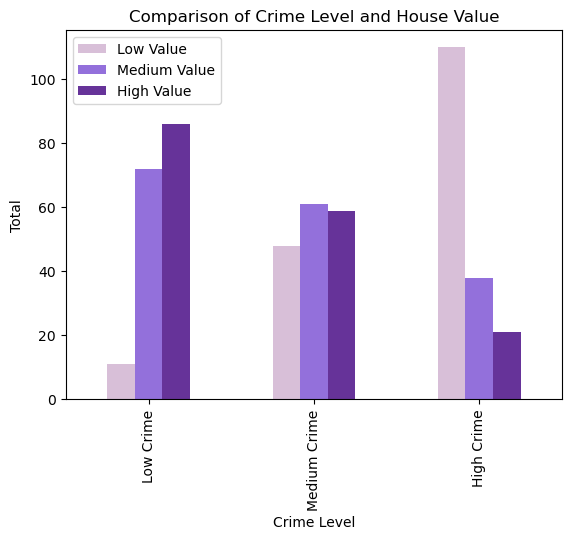

In [10]:
pd.crosstab(Housing["Crime_Level"], 
            Housing["MEDV_Category"]).plot(kind="bar", 
                                           color=["thistle", "mediumpurple", "rebeccapurple"]);

plt.title("Comparison of Crime Level and House Value")
plt.xlabel("Crime Level")
plt.ylabel("Total")
plt.legend(["Low Value", "Medium Value", "High Value"])
plt.show()

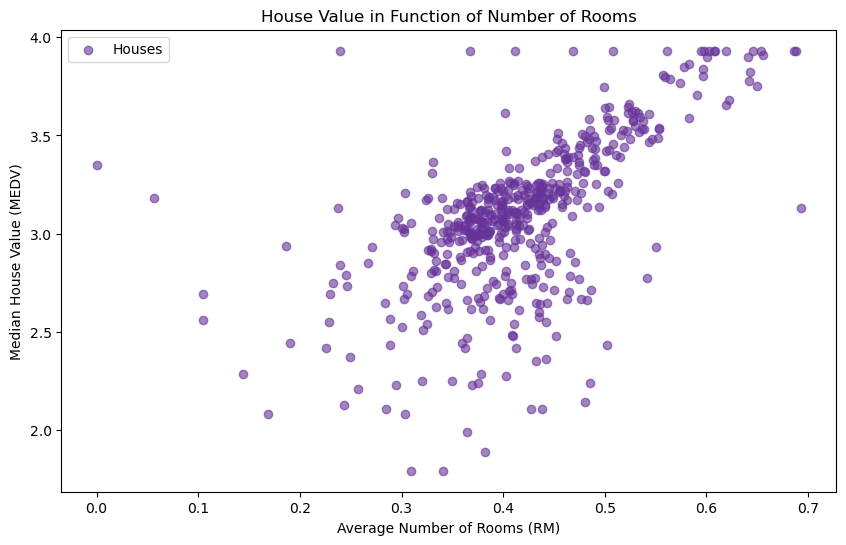

In [11]:
##Checking Correlation between Number of Rooms and House Value
plt.figure(figsize=(10, 6))
plt.scatter(Housing["RM"], Housing ["MEDV"], 
            color="rebeccapurple", 
            alpha=0.6, 
            label="Houses");

plt.title("House Value in Function of Number of Rooms")
plt.xlabel("Average Number of Rooms (RM)")
plt.ylabel("Median House Value (MEDV)")
plt.legend()
plt.show()

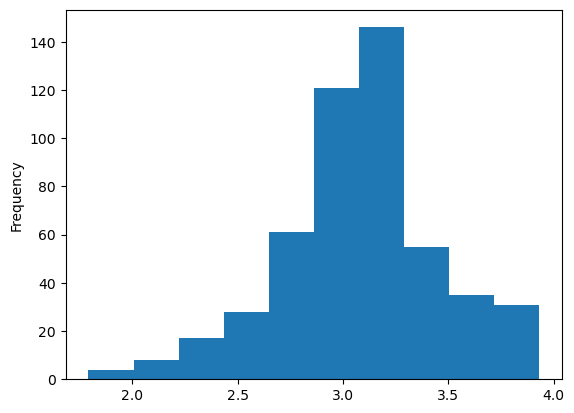

In [12]:
##Distribution of House Values
Housing.MEDV.plot.hist();

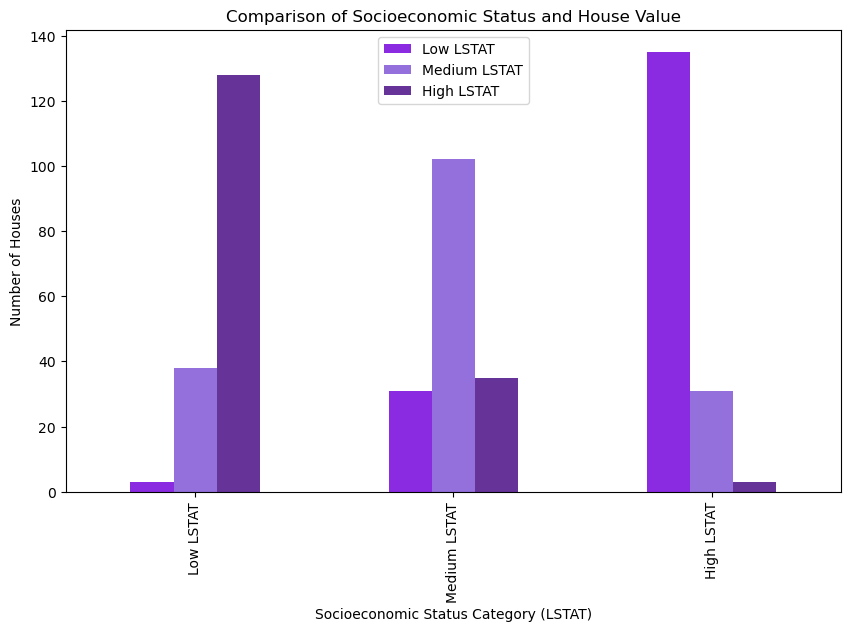

In [13]:
##Relationship between Lower Status Population (LSTAT) and House Value
Housing["LSTAT_Level"] = pd.qcut(Housing["LSTAT"], 
                                 q=3, 
                                 labels=["Low LSTAT", "Medium LSTAT", "High LSTAT"]); 

pd.crosstab(Housing["LSTAT_Level"], 
            Housing["MEDV_Category"]).plot(kind="bar",
                                           figsize=(10,6), 
                                           color=["blueviolet", "mediumpurple", "rebeccapurple"]);

plt.title("Comparison of Socioeconomic Status and House Value")
plt.xlabel("Socioeconomic Status Category (LSTAT)")
plt.ylabel("Number of Houses")
plt.legend(["Low LSTAT", "Medium LSTAT", "High LSTAT"])
plt.show()

In [14]:
##Correlation
hd_corr = Housing.select_dtypes(include='number').corr()
hd_corr

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
CRIM,1.000000,-0.234224,0.450599,-0.056781,0.476531,-0.254630,0.371290,-0.443309,0.682456,0.626683,0.303758,-0.417889,0.488157,-0.552605
ZN,-0.234224,1.000000,-0.552637,-0.042626,-0.575243,0.319252,-0.582854,0.663127,-0.329272,-0.329403,-0.404825,0.177850,-0.447602,0.376076
INDUS,0.450599,-0.552637,1.000000,0.062938,0.778622,-0.394649,0.622307,-0.729265,0.590862,0.717042,0.362812,-0.342996,0.615297,-0.541258
CHAS,-0.056781,-0.042626,0.062938,1.000000,0.083917,0.085432,0.089106,-0.095668,-0.003409,-0.036637,-0.115121,0.050903,-0.056003,0.159435
NOX,0.476531,-0.575243,0.778622,0.083917,1.000000,-0.315791,0.745019,-0.825852,0.625502,0.676497,0.190497,-0.365573,0.609830,-0.513568
RM,-0.254630,0.319252,-0.394649,0.085432,-0.315791,1.000000,-0.242799,0.235376,-0.216814,-0.303379,-0.343648,0.118296,-0.628776,0.621283
AGE,0.371290,-0.582854,0.622307,0.089106,0.745019,-0.242799,1.000000,-0.753761,0.443612,0.483720,0.228336,-0.254685,0.601019,-0.438227
DIS,-0.443309,0.663127,-0.729265,-0.095668,-0.825852,0.235376,-0.753761,1.000000,-0.517500,-0.556501,-0.212319,0.295019,-0.523315,0.359984
RAD,0.682456,-0.329272,0.590862,-0.003409,0.625502,-0.216814,0.443612,-0.517500,1.000000,0.886076,0.442176,-0.437525,0.487880,-0.472155
TAX,0.626683,-0.329403,0.717042,-0.036637,0.676497,-0.303379,0.483720,-0.556501,0.886076,1.000000,0.424395,-0.427695,0.545290,-0.558498


In [15]:
import seaborn as sns

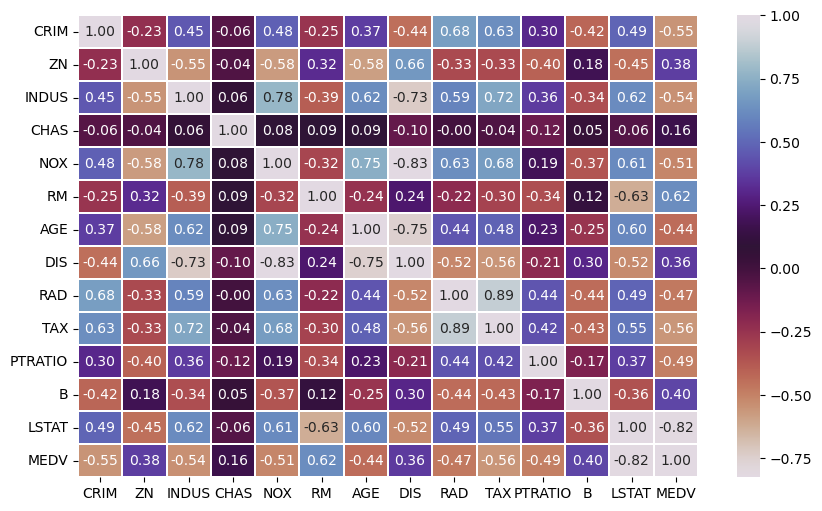

In [16]:
ax,fig = plt.subplots(figsize=(10,6))
ax= sns.heatmap(hd_corr, annot=True, 
                linewidths = 0.2, 
                fmt="0.2f", 
                cmap="twilight_r");

## Building Machine Model

In [17]:
import numpy as np

In [18]:
## Preparing of Tools for modelling

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.metrics import f1_score, precision_score, confusion_matrix, classification_report, recall_score, RocCurveDisplay

## Splitting of Datasets

In [19]:
Housing.head(5)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV,Crime_Level,MEDV_Category,LSTAT_Level
0,0.000000,0.165514,0.067815,0.0,0.273696,0.455845,0.495675,0.238389,0.000000,0.188979,0.252496,0.693147,0.085884,3.218876,Low Crime,High Value,Low LSTAT
1,0.000236,0.000000,0.242302,0.0,0.159428,0.436962,0.578128,0.299335,0.042560,0.099811,0.440312,0.693147,0.186040,3.117950,Low Crime,Medium Value,Medium LSTAT
2,0.000236,0.000000,0.242302,0.0,0.159428,0.527320,0.469617,0.299335,0.042560,0.099811,0.440312,0.688003,0.061533,3.575151,Low Crime,High Value,Low LSTAT
3,0.000293,0.000000,0.063050,0.0,0.139941,0.505947,0.365901,0.370559,0.083382,0.064658,0.500130,0.690281,0.032843,3.538057,Low Crime,High Value,Low LSTAT
4,0.000705,0.000000,0.063050,0.0,0.139941,0.523014,0.424170,0.370559,0.083382,0.064658,0.500130,0.693147,0.094708,3.616309,Low Crime,High Value,Low LSTAT


In [20]:
## Remove categorical/engineered label columns
y = Housing["MEDV"]
x = Housing.drop(columns=["MEDV", "MEDV_Category"], errors="ignore")

In [21]:
## Convert ALL categorical columns properly
X = pd.get_dummies(x, drop_first=True)

In [22]:
## Splitting of data to taining and test
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=45)

In [23]:
## Training of machine model comparing three machine model(KNN, LogisticRegression & RandomForest) for accuracy
models = {
    "KNN Regressor" : KNeighborsRegressor(),
    "Linear Regression" : LinearRegression(),
    "Random Forest Regressor" : RandomForestRegressor(random_state=45)
} 

def model_compare(models, x_train,y_train,x_test,y_test):
    np.random.seed(45)
    model_score = {}
    for names, model in models.items():
        clf = model.fit(x_train,y_train)
        model_score[names] = clf.score(x_test,y_test)
    return model_score

In [24]:
m_compare = model_compare(models=models,
                          x_train=x_train,
                          y_train=y_train,
                          x_test=x_test,
                          y_test=y_test)
m_compare

{'KNN Regressor': 0.7303217337381613,
 'Linear Regression': 0.7843441193444343,
 'Random Forest Regressor': 0.8757579327555346}

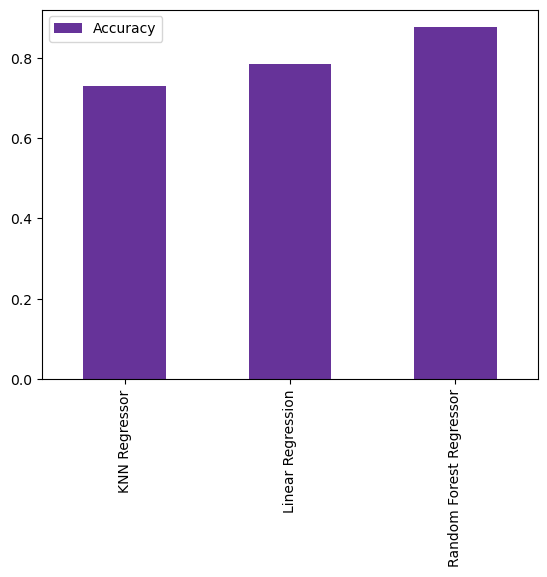

In [25]:
mf = pd.DataFrame(m_compare, index=["Accuracy"])

mf.T.plot.bar(color=["rebeccapurple"]);

## Hyper Parameter Tuning

In [26]:
## Creating a list of values for neighbors
neighbors = range(1, 21)

## Tuning K-NearestNeighbor 
train_score = []
test_score = []

## Looping through different neighbors 
for k in neighbors: 
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(x_train, y_train)

    ## Fit algorithm 
    train_score.append(knn.score(x_train, y_train))
    test_score.append(knn.score(x_test, y_test))

    print(k)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20


The Maximum KNN score on Test Data is: 73.62%


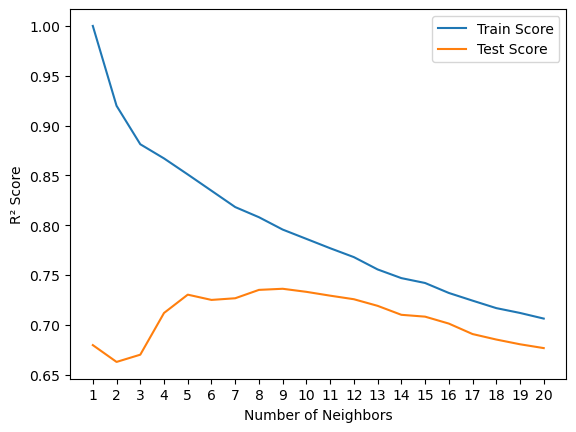

In [27]:
plt.plot(neighbors,train_score,label="Train Score")
plt.plot(neighbors,test_score,label="Test Score")

plt.xlabel("Number of Neighbors")
plt.ylabel("R² Score")
plt.legend()

plt.xticks(np.arange(1,21,1))

print(f'The Maximum KNN score on Test Data is: {max(test_score)*100:.2f}%')

In [28]:
## Tuning of Ridge Regression and RandomForest using RandomizedCV
## Creating parameter grid for Ridge Regression 

from sklearn.linear_model import Ridge

ridge = Ridge()

ridge_param_grid = {
    "alpha": np.logspace(-3, 3, 100),
    "fit_intercept": [True, False],
    "solver": ["auto", "svd", "cholesky", "lsqr"]
}

## Creating parameter grid for RandomForest
rf = RandomForestRegressor(random_state=42)

rf_param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", 0.5]
}

In [29]:
## Tuning Ridge Regression using RandomizedSearchCV

ridge_random = RandomizedSearchCV(
    estimator=Ridge(),
    param_distributions=ridge_param_grid,
    n_iter=20,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

ridge_random.fit(x_train, y_train)

print("Best Ridge Params:", ridge_random.best_params_)
print("Best Ridge Score:", ridge_random.best_score_)

Best Ridge Params: {'solver': 'lsqr', 'fit_intercept': True, 'alpha': np.float64(0.0030538555088334154)}
Best Ridge Score: 0.7806600397296932


In [30]:
ridge_random.best_params_

{'solver': 'lsqr',
 'fit_intercept': True,
 'alpha': np.float64(0.0030538555088334154)}

In [31]:
ridge_random.score(x_test,y_test)

0.7844378660893958

In [32]:
## Tuning of RandomForest using RandomSearchCV
rf_cv = RandomizedSearchCV(estimator=rf,
                           param_distributions=rf_param_grid,
                           cv=5, 
                           n_iter=20,
                           verbose=1, 
                           random_state=42,
                           n_jobs=-1)

rf_cv.fit(x_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used h

In [33]:
rf_cv.best_params_

{'n_estimators': 200,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_features': 'log2',
 'max_depth': 30}

In [34]:
rf_cv.score(x_test,y_test)

0.8883438601639632

In [35]:
## Tuning of Ridge Regression using GridSearchCV
## Creating parameter grid for Ridge Regression 

ridge = Ridge()

param_grid = {
    "alpha": np.logspace(-3, 3, 50),
    "fit_intercept": [True, False],
    "solver": ["auto", "svd", "cholesky", "lsqr"]
}

grid_search = GridSearchCV(estimator=ridge,
                           param_grid=param_grid,
                           cv=5,
                           scoring="r2",
                           n_jobs=-1)

grid_search.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Ridge()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': array([1.0000...00000000e+03]), 'fit_intercept': [True, False], 'solver': ['auto', 'svd', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score 

In [36]:
grid_search.best_params_

{'alpha': np.float64(0.06866488450043001),
 'fit_intercept': True,
 'solver': 'lsqr'}

In [37]:
grid_search.score(x_test,y_test)

0.7860556182690576

In [38]:
y_preds = grid_search.predict(x_test)
y_preds

array([2.58720196, 3.16736483, 3.14917097, 3.09150765, 3.59558614,
       2.74139242, 2.93658174, 3.03403754, 3.34360325, 2.92490665,
       2.56631436, 2.94529084, 3.58190146, 3.17900865, 2.85351197,
       3.0302079 , 3.26425842, 2.58933537, 2.6033205 , 3.15150309,
       3.13422709, 2.92155862, 3.10866133, 3.4336321 , 3.09071761,
       3.29709378, 3.17537938, 2.22893421, 3.24288183, 2.98709657,
       3.04017366, 2.40983041, 3.32632319, 3.1790414 , 3.70878094,
       3.27804561, 3.77702868, 2.1889154 , 3.48791089, 3.52657885,
       3.00478537, 3.08318657, 2.83153547, 3.46327227, 2.94439756,
       2.75585474, 3.30861966, 3.34415912, 2.91617757, 3.10222476,
       3.80961985, 3.02313365, 3.29892591, 3.49713909, 2.93447865,
       3.41253929, 2.29151616, 2.72360267, 2.96944978, 3.07370763,
       2.6601848 , 2.80812209, 3.6551697 , 3.62945939, 2.83260406,
       2.72996037, 3.70955784, 3.64148236, 3.0619589 , 3.04635566,
       3.63688611, 3.01077271, 3.16680931, 2.74077984, 2.55214

## Evaluation Metrics

In [39]:
## Import R² metric
from sklearn.metrics import r2_score

## Predict on test data
y_pred = grid_search.predict(x_test)

## Compute R² score
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.7860556182690576


In [40]:
## Import MAE metric
from sklearn.metrics import mean_absolute_error

## Compute MAE
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 0.14718872527277652


In [41]:
## Import MSE metric
from sklearn.metrics import mean_squared_error

## Compute MSE
mse = mean_squared_error(y_test, y_pred)

## Convert to RMSE for interpretability
rmse = np.sqrt(mse)

print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)

Mean Squared Error: 0.039434384822188216
Root Mean Squared Error: 0.19858092763956012


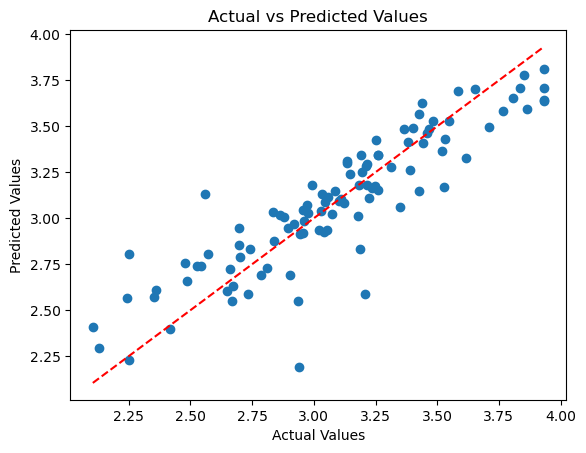

In [42]:
## Actual vs Predicted Plot
## Scatter plot of actual vs predicted values
plt.scatter(y_test, y_pred)

## Perfect prediction reference line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")

plt.show()

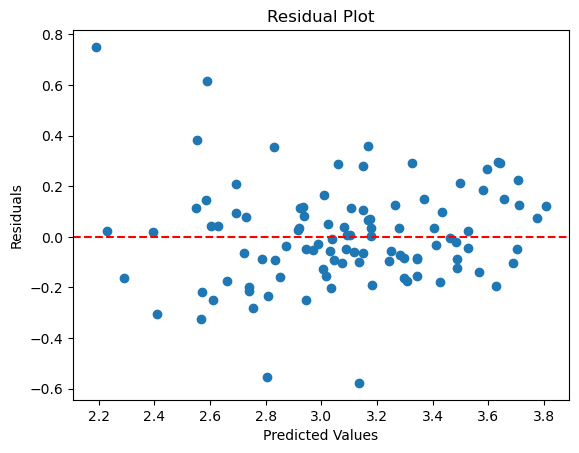

In [43]:
## Residual Plot 
## Compute residuals (errors)
residuals = y_test - y_pred

## Plot residuals against predictions
plt.scatter(y_pred, residuals)

# Zero error reference line
plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

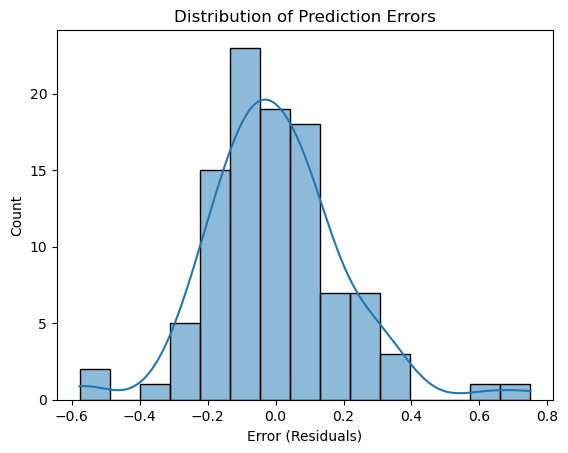

In [44]:
## Error Distribution 
# Plot distribution of residuals
sns.histplot(residuals, kde=True)

plt.title("Distribution of Prediction Errors")
plt.xlabel("Error (Residuals)")

plt.show()

## Feature Importance

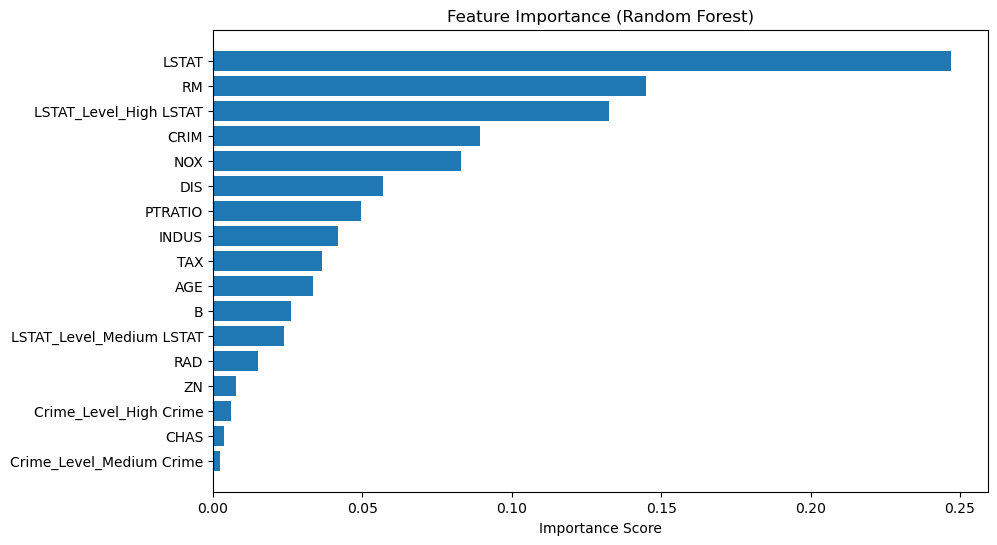

In [45]:
## Get the best trained Random Forest model 
rf_model = rf_cv.best_estimator_ 

## Get feature importance from trained model
importances = rf_model.feature_importances_

## Get feature names
features = X.columns

## Create DataFrame for better visualization
feature_importance = pd.DataFrame({"Feature": features,
                                   "Importance": importances})

## Sort values
feature_importance = feature_importance.sort_values(by="Importance", ascending=True)

plt.figure(figsize=(10,6))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])

plt.xlabel("Importance Score")
plt.title("Feature Importance (Random Forest)")

plt.show()

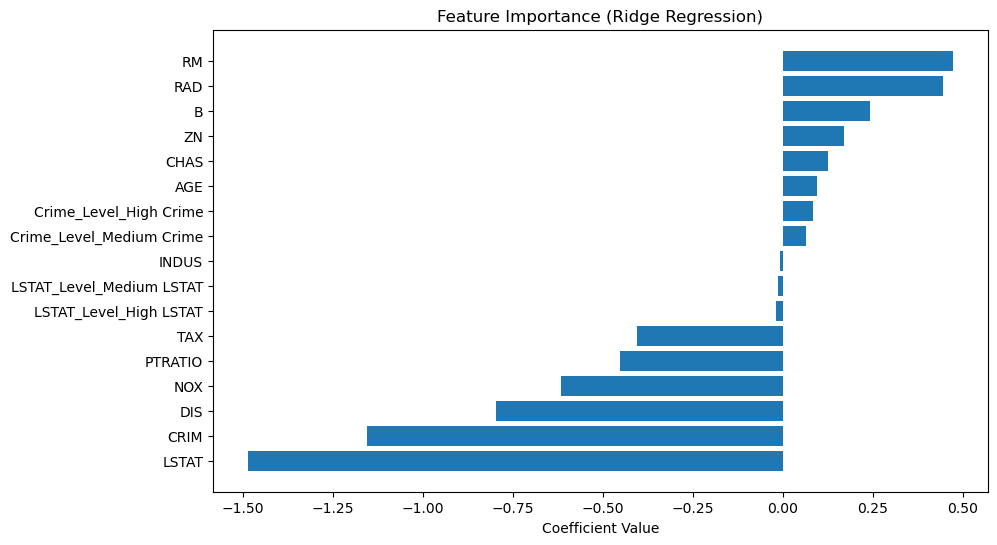

In [46]:
## Get the best Ridge model from GridSearchCV 
ridge_model = grid_search.best_estimator_ 

## Get coefficients from Ridge model
coefficients = ridge_model.coef_

## Feature names
features = X.columns

## Create DataFrame
coef_df = pd.DataFrame({"Feature": features,
                        "Coefficient": coefficients})

## Sort by coefficient strength
coef_df = coef_df.sort_values(by="Coefficient")

plt.figure(figsize=(10,6))
plt.barh(coef_df["Feature"], coef_df["Coefficient"])

plt.xlabel("Coefficient Value")
plt.title("Feature Importance (Ridge Regression)")

plt.show()